In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score # Added cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline # Renamed for clarity
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1 - Loading Data \& Preprocessing

In [4]:
df = pd.read_csv('normalized_labeled_data.csv')
print(f"Initial dataset shape: {df.shape}")
print(df.head())

Initial dataset shape: (8411, 26)
   index  EventType             EventDate  HasSafetyRec  Mode  \
0      0          1  2020-12-31T18:15:00Z         False     0   
1      1          0  2020-12-31T18:00:00Z         False     0   
2      2          0  2020-12-31T15:45:00Z         False     0   
3      3          0  2020-12-31T14:49:00Z         False     0   
4      4          1  2020-12-31T02:15:00Z         False     0   

  OriginalPublishedDate HighestInjuryLevel FatalInjuryCount  \
0        12/2/2022 0:00                  ?              0.0   
1        9/20/2021 0:00                  ?              0.0   
2       10/19/2021 0:00              Minor              0.0   
3                     ?                  ?              0.0   
4                     ?                  ?                ?   

  SeriousInjuryCount MinorInjuryCount OnboardInjuryCount  Make  Model  \
0                0.0              0.0                0.0   250    303   
1                0.0              0.0             

In [5]:
# Handle '?' and Empty Strings
df.replace('?', np.nan, inplace=True)
df.replace('', np.nan, inplace=True)

In [6]:
# Drop Unnecessary Columns
df.drop('index', axis=1, inplace=True)
df.drop('OriginalPublishedDate', axis=1, inplace=True)

In [7]:
print(df['HighestInjuryLevel'].value_counts(dropna=False))

HighestInjuryLevel
NaN        4861
Fatal      1578
Minor      1074
Serious     898
Name: count, dtype: int64


In [8]:
# Define Target Variable and Handle Data Leakage
TARGET_COLUMN = 'FatalYN'
leaky_features = [
    'HighestInjuryLevel', 'FatalInjuryCount', 'SeriousInjuryCount',
    'MinorInjuryCount', 'OnboardInjuryCount'
]

existing_leaky_features = [col for col in leaky_features if col in df.columns]
df.drop(columns=existing_leaky_features, inplace=True, errors='ignore')

In [9]:
# Feature Engineering
df['EventDate'] = pd.to_datetime(df['EventDate'], errors='coerce')
df['EventYear'] = df['EventDate'].dt.year
df['EventMonth'] = df['EventDate'].dt.month
df['EventDay'] = df['EventDate'].dt.day
df['EventDayOfWeek'] = df['EventDate'].dt.dayofweek
df['EventHour'] = df['EventDate'].dt.hour
df.drop('EventDate', axis=1, inplace=True)

# Boolean Conversion
bool_cols_map = {'HasSafetyRec': {True: 1, False: 0}, 'AmateurBuilt': {True: 1, False: 0}}
for col, mapping in bool_cols_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

truly_numerical_features = ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour']

# Add HasSafetyRec and AmateurBuilt and scale them
truly_numerical_features.append('HasSafetyRec')
truly_numerical_features.append('AmateurBuilt')

truly_numerical_features = [col for col in truly_numerical_features if col in df.columns]

# All other features (that are not the target and not in truly_numerical_features) will be treated as categorical and converted to string for one-hot encoding.
all_features = df.drop(TARGET_COLUMN, axis=1).columns.tolist()
features_to_make_categorical_str = [
    col for col in all_features if col not in truly_numerical_features
]

print(f"Features to be treated as numeric (for scaling): {truly_numerical_features}")
print(f"Features to be converted to string and one-hot encoded: {features_to_make_categorical_str}")

for col in features_to_make_categorical_str:
    if col in df.columns:
        df[col] = df[col].astype(str) # Convert to string to ensure one-hot encoding

Features to be treated as numeric (for scaling): ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'HasSafetyRec', 'AmateurBuilt']
Features to be converted to string and one-hot encoded: ['EventType', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType']


In [10]:
print("df.info() after type conversions:")
df.info()
print("\ndf.head() after type conversions:")
print(df.head())

# Drop rows where target is NaN
df.dropna(subset=[TARGET_COLUMN], inplace=True)
# Ensure target is integer
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

print(f"\nShape after dropping rows with NaN in target: {df.shape}")
print(f"Target '{TARGET_COLUMN}' value counts:\n{df[TARGET_COLUMN].value_counts(normalize=True)}")

df.info() after type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8411 entries, 0 to 8410
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EventType             8411 non-null   object
 1   HasSafetyRec          8411 non-null   int64 
 2   Mode                  8411 non-null   object
 3   Make                  8411 non-null   object
 4   Model                 8411 non-null   object
 5   AirCraftCategory      8411 non-null   object
 6   AirportID             8411 non-null   object
 7   AmateurBuilt          8411 non-null   int64 
 8   NumberOfEngines       8411 non-null   object
 9   EngineType            8411 non-null   object
 10  PurposeOfFlight       8411 non-null   object
 11  FAR                   8411 non-null   object
 12  AirCraftDamage        8411 non-null   object
 13  WeatherCondition      8411 non-null   object
 14  BroadPhaseofFlight    8411 non-null   object
 15  Repo

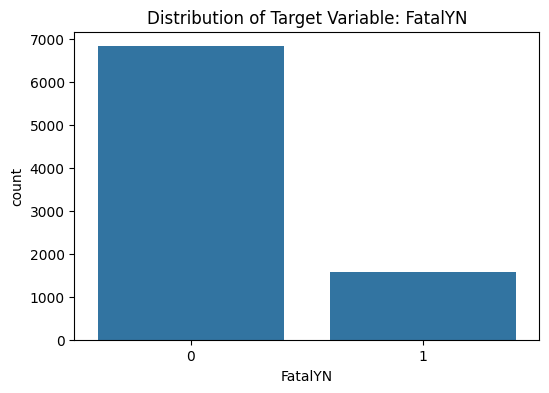

In [11]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title(f'Distribution of Target Variable: {TARGET_COLUMN}')
plt.show()

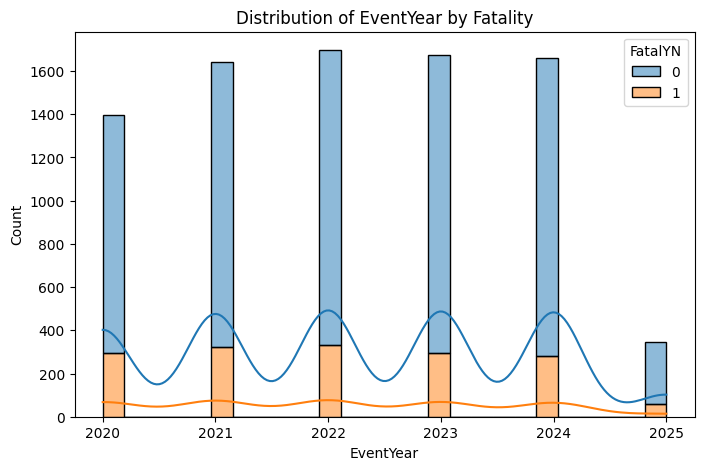

In [12]:
# Distribution of a numerical feature (EventYear)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='EventYear', hue=TARGET_COLUMN, kde=True, multiple="stack")
plt.title('Distribution of EventYear by Fatality')
plt.show()

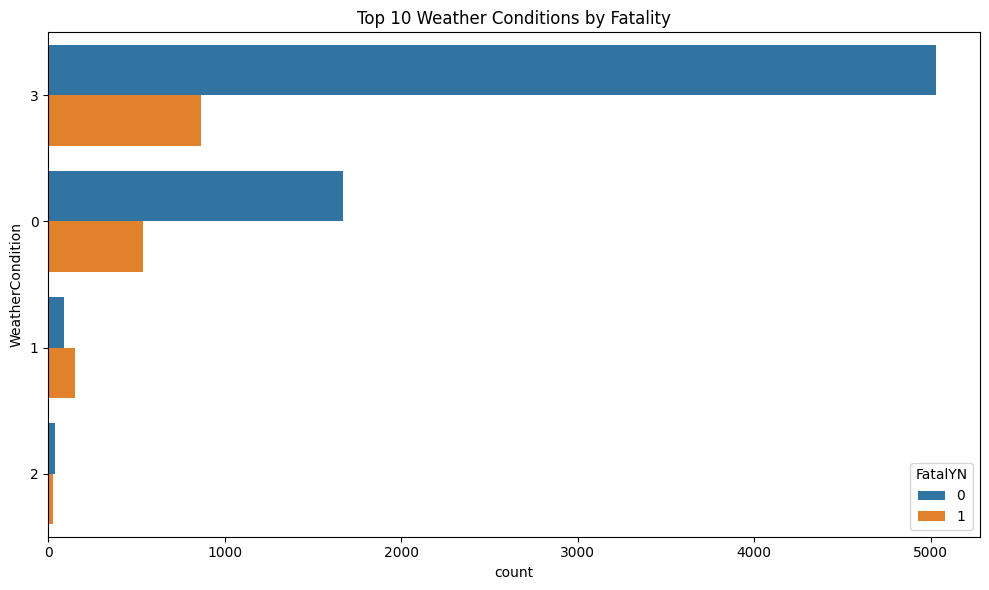

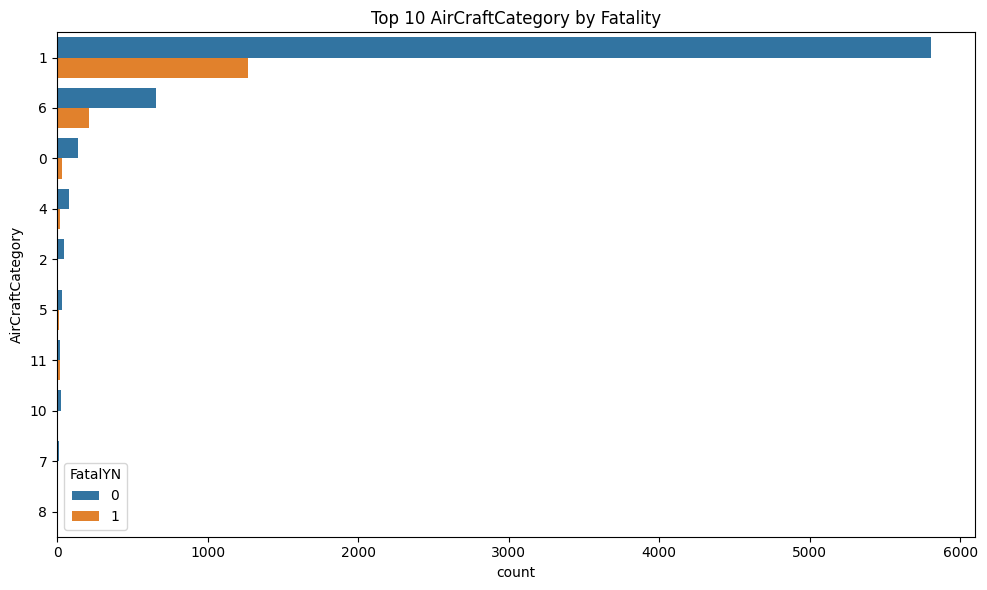

In [13]:
# Distribution of Catagorical Features

top_n = 10
plt.figure(figsize=(10, 6))
top_categories = df['WeatherCondition'].value_counts().nlargest(top_n).index
sns.countplot(y='WeatherCondition', hue=TARGET_COLUMN, data=df[df['WeatherCondition'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} Weather Conditions by Fatality')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_categories = df['AirCraftCategory'].value_counts().nlargest(top_n).index
sns.countplot(y='AirCraftCategory', hue=TARGET_COLUMN, data=df[df['AirCraftCategory'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} AirCraftCategory by Fatality')
plt.tight_layout()
plt.show()

# Train-Test Split

In [14]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [15]:
numerical_features_for_pipeline = [col for col in truly_numerical_features if col in X.columns]
categorical_features_for_pipeline = [col for col in features_to_make_categorical_str if col in X.columns]

print(f"Features for X: {X.columns.tolist()}")
print(f"Numerical features for pipeline: {numerical_features_for_pipeline}")
print(f"Categorical features for pipeline: {categorical_features_for_pipeline}")

Features for X: ['EventType', 'HasSafetyRec', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'AmateurBuilt', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType', 'EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour']
Numerical features for pipeline: ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'HasSafetyRec', 'AmateurBuilt']
Categorical features for pipeline: ['EventType', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (6728, 22), X_test shape: (1683, 22)
y_train distribution:
FatalYN
0    0.812426
1    0.187574
Name: proportion, dtype: float64
y_test distribution:
FatalYN
0    0.81224
1    0.18776
Name: proportion, dtype: float64


## --- Categorical Encoding & Scaling ---

In [17]:
# Numerical pipeline
numerical_pipeline = SklearnPipeline([
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = SklearnPipeline([
    ('imputer_cat', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features_for_pipeline),
        ('cat', categorical_pipeline, categorical_features_for_pipeline)
    ],
    remainder='drop'
)

# Apply transformations
print("Fitting and transforming X_train")
X_train_processed = preprocessor.fit_transform(X_train)

# Get feature names after one-hot encoding for better interpretability

feature_names_out = preprocessor.get_feature_names_out()
print(f"Number of features after preprocessing: {len(feature_names_out)}")


print("Transforming X_test")
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Fitting and transforming X_train
Number of features after preprocessing: 5674
Transforming X_test
X_train_processed shape: (6728, 5674)
X_test_processed shape: (1683, 5674)


In [18]:
use_smote = True

# Oversample Minority Class for Class Imbalance using SMOTE

In [21]:
if use_smote and y_train.value_counts().min() >= 6:
    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_train_processed, y_train)
    print(f"Shape of X_train after SMOTE: {X_train_final.shape}")
    print(f"Distribution of y_train after SMOTE:\n{pd.Series(y_train_final).value_counts(normalize=True)}")
else:
    print("\nSMOTE failed due to insufficient samples")
    X_train_final, y_train_final = X_train_processed, y_train

Shape of X_train after SMOTE: (10932, 5674)
Distribution of y_train after SMOTE:
FatalYN
0    0.5
1    0.5
Name: proportion, dtype: float64


# KNN

In [22]:

k_values = [3, 5, 7, 10, 15, 20]
best_k = k_values[0]
best_f1_fatal = -1 # Initialize with a value lower than any possible F1-score

# To store metrics for plotting later
k_results = {'k': [], 'accuracy': [], 'f1_fatal': [], 'roc_auc': []}

for k in k_values:
    print(f"\n--- Training KNN with k = {k} ---")
    knn_model = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski', p=2) # p=2 is Euclidean distance

    # Training
    knn_model.fit(X_train_final, y_train_final)

    # Predictions
    y_pred_classes_knn = knn_model.predict(X_test_processed)
    y_pred_proba_knn = knn_model.predict_proba(X_test_processed)[:, 1] # Probabilities for the positive class


--- Training KNN with k = 3 ---

--- Training KNN with k = 5 ---

--- Training KNN with k = 7 ---

--- Training KNN with k = 10 ---

--- Training KNN with k = 15 ---

--- Training KNN with k = 20 ---


## Evaluation


Classification Report for k = 20:
               precision    recall  f1-score   support

Not Fatal (0)       0.96      0.58      0.72      1367
    Fatal (1)       0.33      0.89      0.48       316

     accuracy                           0.64      1683
    macro avg       0.64      0.73      0.60      1683
 weighted avg       0.84      0.64      0.67      1683

Accuracy for k=20: 0.6358
F1-score for Fatal (1) for k=20: 0.4792
ROC AUC for k=20: 0.8240

Best k based on F1-score for Fatal class: 20 (F1-score: 0.4792)

--- Visualizations for Best KNN Model (k=20) ---


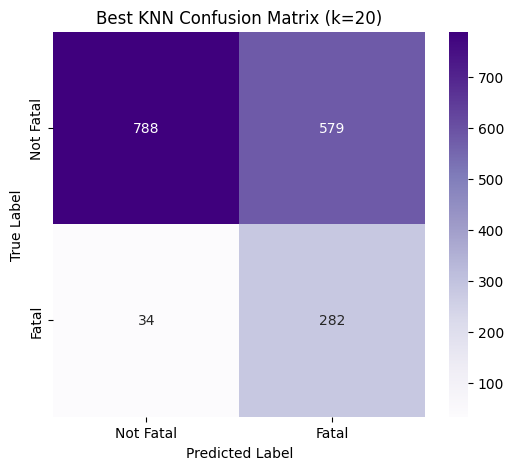

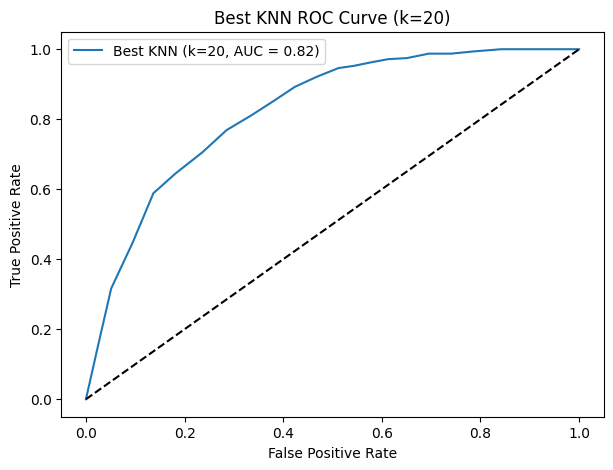

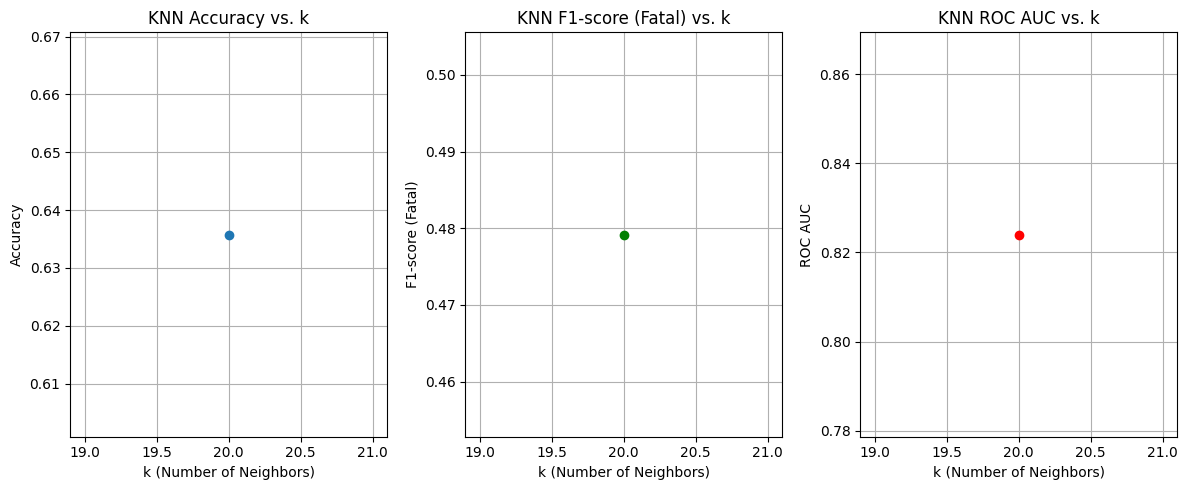

In [24]:
print(f"\nClassification Report for k = {k}:")
report = classification_report(y_test, y_pred_classes_knn, target_names=['Not Fatal (0)', 'Fatal (1)'], output_dict=True)
print(classification_report(y_test, y_pred_classes_knn, target_names=['Not Fatal (0)', 'Fatal (1)']))

accuracy = accuracy_score(y_test, y_pred_classes_knn)
f1_fatal = report['Fatal (1)']['f1-score']
roc_auc = roc_auc_score(y_test, y_pred_proba_knn)

k_results['k'].append(k)
k_results['accuracy'].append(accuracy)
k_results['f1_fatal'].append(f1_fatal)
k_results['roc_auc'].append(roc_auc)

print(f"Accuracy for k={k}: {accuracy:.4f}")
print(f"F1-score for Fatal (1) for k={k}: {f1_fatal:.4f}")
print(f"ROC AUC for k={k}: {roc_auc:.4f}")

if f1_fatal > best_f1_fatal:
    best_f1_fatal = f1_fatal
    best_k = k
    # Store best model's predictions for final visualizations
    best_y_pred_classes_knn = y_pred_classes_knn
    best_y_pred_proba_knn = y_pred_proba_knn

print(f"\nBest k based on F1-score for Fatal class: {best_k} (F1-score: {best_f1_fatal:.4f})")

# --- Final Evaluation Visualizations for the Best KNN Model ---
print(f"\n--- Visualizations for Best KNN Model (k={best_k}) ---")

# Confusion Matrix for the best k
cm_knn_best = confusion_matrix(y_test, best_y_pred_classes_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn_best, annot=True, fmt='d', cmap='Purples', xticklabels=['Not Fatal', 'Fatal'], yticklabels=['Not Fatal', 'Fatal'])
plt.title(f'Best KNN Confusion Matrix (k={best_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve for the best k
auc_knn_best = roc_auc_score(y_test, best_y_pred_proba_knn)
fpr_knn_best, tpr_knn_best, _ = roc_curve(y_test, best_y_pred_proba_knn)
plt.figure(figsize=(7, 5))
plt.plot(fpr_knn_best, tpr_knn_best, label=f'Best KNN (k={best_k}, AUC = {auc_knn_best:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Best KNN ROC Curve (k={best_k})')
plt.legend()
plt.show()

# Plot performance vs. k
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(k_results['k'], k_results['accuracy'], marker='o')
plt.title('KNN Accuracy vs. k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(k_results['k'], k_results['f1_fatal'], marker='o', color='green')
plt.title('KNN F1-score (Fatal) vs. k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('F1-score (Fatal)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(k_results['k'], k_results['roc_auc'], marker='o', color='red')
plt.title('KNN ROC AUC vs. k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('ROC AUC')
plt.grid(True)

plt.tight_layout()
plt.show()